# Agilent LCR & Janis Temperature Controller
Automated Measurements with Live Plotting

In [1]:
# Imports
from nfoinstruments.drivers import Janis, E4890A
from nfoinstruments.drivers.setup import MeasurementSetup
from nfoinstruments.procedures import (
    set_temperature_and_wait, 
    sweep_frequency_lcr,
    single_frequency_time_scan,
    set_bias_and_wait,
    build_cv_bias_path,
    sweep_cv_lcr,
    load_measurement_files,
    load_cv_measurement_files,
    plot_all_measurements,
    plot_measurement_comparison,
    plot_time_scan_comparison,
    plot_cv_comparison
)
from nfoinstruments.procedures.utils import (
    run_temperature_bias_sweep_with_live_plot, 
    run_cv_sweep_with_live_plot,
    run_time_scan_with_live_plot,
    plot_is_overlay,
    plot_cv_overlay,
    plot_time_scan_overlay,
    load_and_plot_is,
    load_and_plot_cv,
    load_and_plot_time_scan
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Output configuration
output_path = Path(r"C:\Users\F110216\Desktop\Data_Horatio\UCL111")

In [2]:
# Initialize instruments
mm = MeasurementSetup()

# Connect to devices (update GPIB addresses if needed)
mm.connect_to_devices({
    'GPIB0::16::INSTR': Janis,
    'GPIB1::17::INSTR': E4890A
})

janis = mm.devices['GPIB0::16::INSTR']
lcr = mm.devices['GPIB1::17::INSTR']

# Configure LCR meter
lcr.measurement_type = E4890A.MeasurementType.ZTD  # Options: ZTD (Z, θ), RX (R, X), CPD (Cp, D), CSD (Cs, D)...
lcr.measurement_time = E4890A.MeasurementTime.LONG # Options: SHORT, MEDIUM, LONG
lcr.averages = 1                                 # 1 to 256
lcr.signal_type = E4890A.SignalType.VOLTAGE        # VOLTAGE or CURRENT
lcr.alc_enabled = False                            # Automatic Level Control (True/False) - MUST BE FALSE TO PROTECT MEMRISTOR

# Initialize into Standby Mode (Protect Sample during probe landing)
print("Initializing LCR into STANDBY MODE...")
lcr.signal_amplitude = 0.0                       # Signal Amplitude (V or A)
lcr.bias = 0.0                                     # DC Bias (V)
lcr.trigger_source = 'BUS'                        # Stop internal measurements (protects from bridge overload)

print(f"LCR configured:")
print(f"  Type: {lcr.measurement_type.name}")
print(f"  Time: {lcr.measurement_time.name} (Avg: {lcr.averages})")
print(f"  ALC: {lcr.alc_enabled}")
print(f"  AC Signal: {lcr.signal_amplitude} V")
print(f"  DC Bias: {lcr.bias} V")
print(f"  Trigger: {lcr.trigger_source}")

['GPIB0::15::INSTR', 'GPIB0::17::INSTR', 'GPIB0::18::INSTR', 'GPIB0::22::INSTR', 'GPIB1::15::INSTR', 'GPIB1::17::INSTR', 'GPIB0::16::INSTR']
LCR Connected: Agilent Technologies,E4980A,MY46204018,A.06.17
{'_alc_enabled': True,
 '_averages': 1,
 '_bias': 0,
 '_frequency': 100,
 '_measurement_time': <MeasurementTime.MEDIUM: 'MED'>,
 '_measurement_type': <MeasurementType.RX: 'RX'>,
 '_signal_amplitude': 1,
 '_signal_type': <SignalType.VOLTAGE: 2>,
 '_trigger_source': 'INT',
 'address': 'GPIB1::17::INSTR',
 'measurement_timeout': 20,
 'resource': <'GPIBInstrument'('GPIB1::17::INSTR')>}
Initializing LCR into STANDBY MODE...
LCR configured:
  Type: ZTD
  Time: LONG (Avg: 1)
  ALC: False
  AC Signal: 0.0 V
  DC Bias: 0.0 V
  Trigger: BUS


## Optional: Parasitic Calibration

In [3]:
# ====================================================================
# PERFORM NEW OPEN/SHORT CORRECTIONS (Run once per setup)
# ====================================================================
# Set to True ONLY when you want to physically perform the calibration sweep.
# The instrument will save the calibration arrays in its memory.
cable_calibration = False
short_calibration = False
open_calibration = False
# Cable Length Correction (Valid options: 0, 1, 2, or 4 meters).
# 0m means NO cable length correction is applied (default state).
cable_length_m = 1

if cable_calibration:
    # Set cable length correction before sweeping Open/Short
    lcr.correction_length = cable_length_m
    print(f"Cable Length Correction set to: {cable_length_m}m")

if short_calibration:
    print("--- SHORT CORRECTION ---")
    input("1. Land probes on shorting pad (or touch together). 2. Press ENTER to begin Short Correction...")
    print("Measuring Short Correction (this will take a moment)...")
    lcr.perform_short_correction()
    print("Short Correction completed!")
    lcr.correction_short_enabled = True

if open_calibration:
    print("--- OPEN CORRECTION ---")
    input("1. Lift probes to measurement height in air. 2. Press ENTER to begin Open Correction...")
    print("Measuring Open Correction (this will take a moment)...")
    lcr.perform_open_correction()
    print("Open Correction completed!")
    lcr.correction_open_enabled = True
    


In [4]:
# ====================================================================
# TOGGLE EXISTING CORRECTIONS
# ====================================================================
# Toggle the saved corrections ON or OFF without remeasuring.
# Turn this off if you suspect the calibration is interfering with raw data.
enable_corrections = True

# Cable Length Correction (Valid options: 0, 1, 2, or 4 meters).
# 0m means NO cable length correction is applied.
cable_length_m = 1

if enable_corrections:
    lcr.correction_length = cable_length_m
    lcr.correction_open_enabled = False
    lcr.correction_short_enabled = False
    print(f"Parasitic Corrections are currently: ENABLED (Cable: {cable_length_m}m).")
else:
    lcr.correction_length = 0
    lcr.correction_open_enabled = False
    lcr.correction_short_enabled = False
    print("Parasitic Corrections are currently: DISABLED (Cable: 0m).")

Parasitic Corrections are currently: ENABLED (Cable: 1m).


## Manual LCR & Temperature Control
Run this cell to manually activate/deactivate the LCR output or manually set the Janis temperature.

In [64]:
# --- MANUAL STANDBY TOGGLE ---

# Uncomment to ACTIVATE signal
# lcr.signal_amplitude = 0.05
# lcr.trigger_source = 'INT'
# print(f"Signal ACTIVE: {lcr.signal_amplitude} V, Trigger: INT")

# Uncomment to DEACTIVATE signal (Standby)
lcr.signal_amplitude = 0.0
lcr.bias = 0.0
lcr.trigger_source = 'BUS'
print(f"Signal DEACTIVATED (Standby mode: 0V, BUS)")

# --- MANUAL TEMPERATURE CONTROL ---
# Uncomment to manually set Janis temperature
set_temperature_and_wait(janis, target_temp=300, extra_settle_time=30, verbose=True)



Signal DEACTIVATED (Standby mode: 0V, BUS)
Setting temperature to 300 K...
Waiting for temperature stability...


KeyboardInterrupt: 

## 1. Initial (Pristine) IS Sweep
Do a single sweep at the current temperature before the main loop.

In [ ]:
# Define parameters for Pristine Sweep
# 60 points per decade, from 20 Hz to 2 MHz (5 decades -> 300 points)
frequencies = np.round(np.logspace(np.log10(20), np.log10(2e6), num=200), decimals=2)

current_temp = janis.temperature
dc_biases = [0.0, -2.0, -1.0, 0.0, 1.0, 2.0, 0.0]  # V
ac_amplitude = 0.05 # V

#sweep_name = "dev6_F_padonly"
#sweep_name = "dev6_B_padonly"
#sweep_name = "dev6_N_padonly"
#sweep_name = "dev7_C_formed"
sweep_name = "dev12_J"
#next_run = 1
# Run pristine measurement
next_run = run_temperature_bias_sweep_with_live_plot(
    parent_dir=output_path,
    sweep_name=sweep_name,
    temp_points=[current_temp],
    bias_points=dc_biases,
    janis_ctrl=janis,
    lcr_ctrl=lcr,
    freq_points=frequencies,
    Vrms=ac_amplitude,
    filename_suffix="_HRS", 
    run_count_start= next_run,
    run_select=None,
    extra_settle_time=0,
    log_y_left=True,   # log scale for Magnitude / Modulus Real
    log_y_right=False,  # linear scale for Phase / Modulus Imaginary
    #y_range_left=[1e1,1e6],        # e.g. (1e3, 1e7)
    remove_outliers= True,
)


Temperature: 300.072 K
Already at target temperature (300.072 K).

  Bias: +0.00 V
  Measuring -> run002_temp_300_DC_pos0.00V_HRS.csv ...
Activating LCR signal amplitude to 0.05 V and trigger BUS...
    Progress: 50/200 points
    Progress: 100/200 points


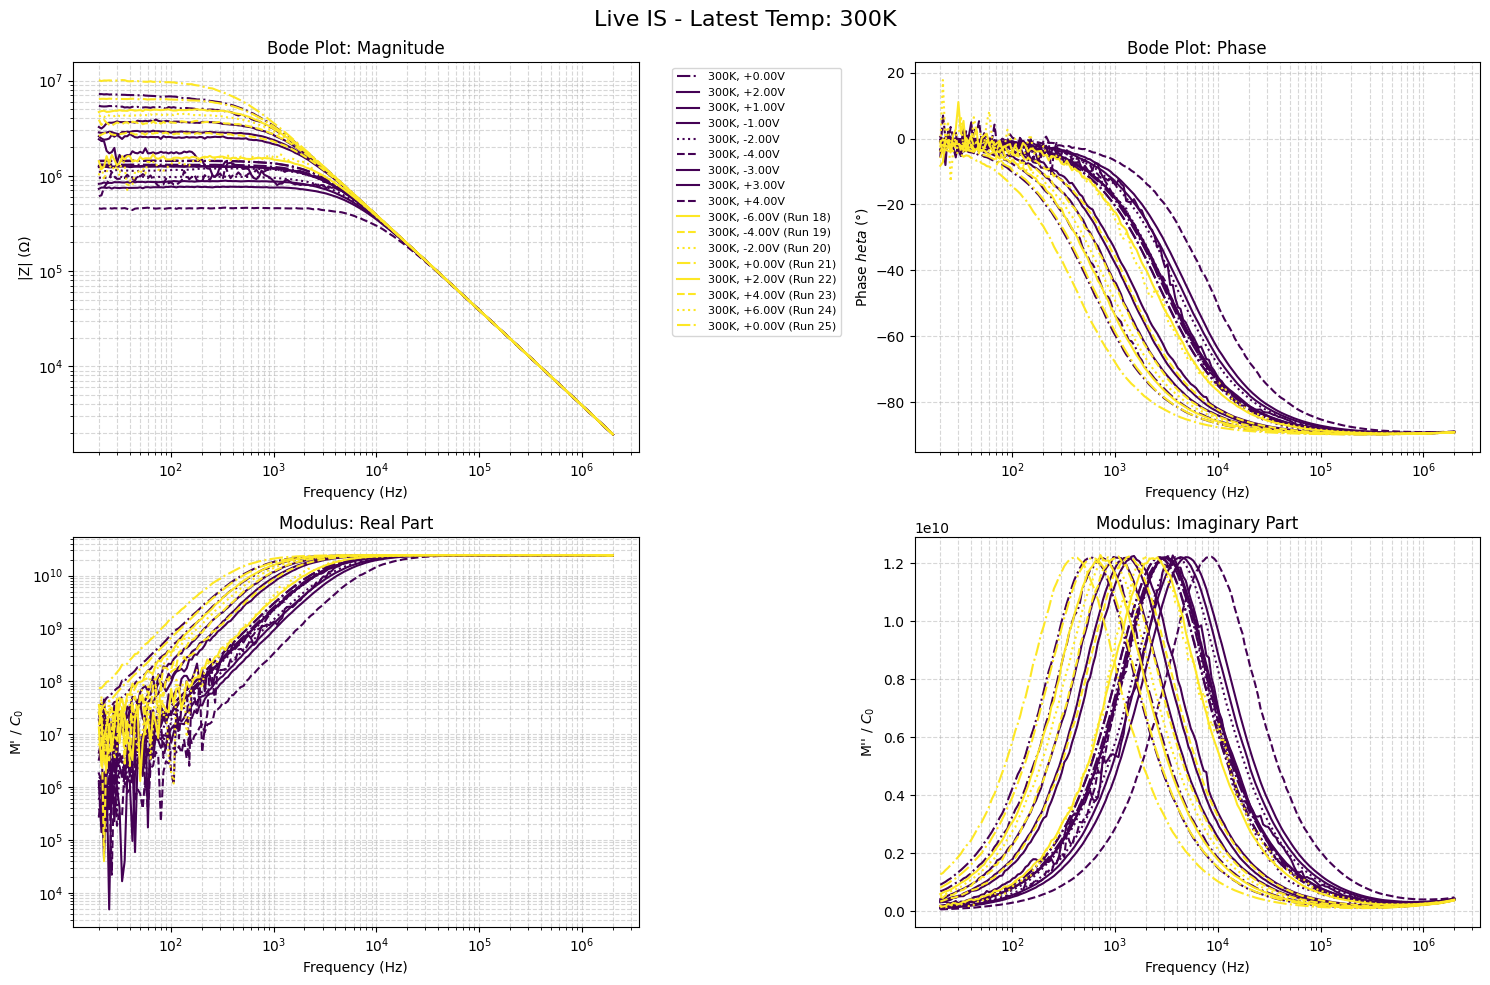


Putting LCR into true standby mode (0V AC, 0V DC, Trigger BUS)...

✓ ALL MEASUREMENTS COMPLETE! Next run: 26


### Plot IS Measurements (Standalone)
Run this to re-plot without taking new measurements.

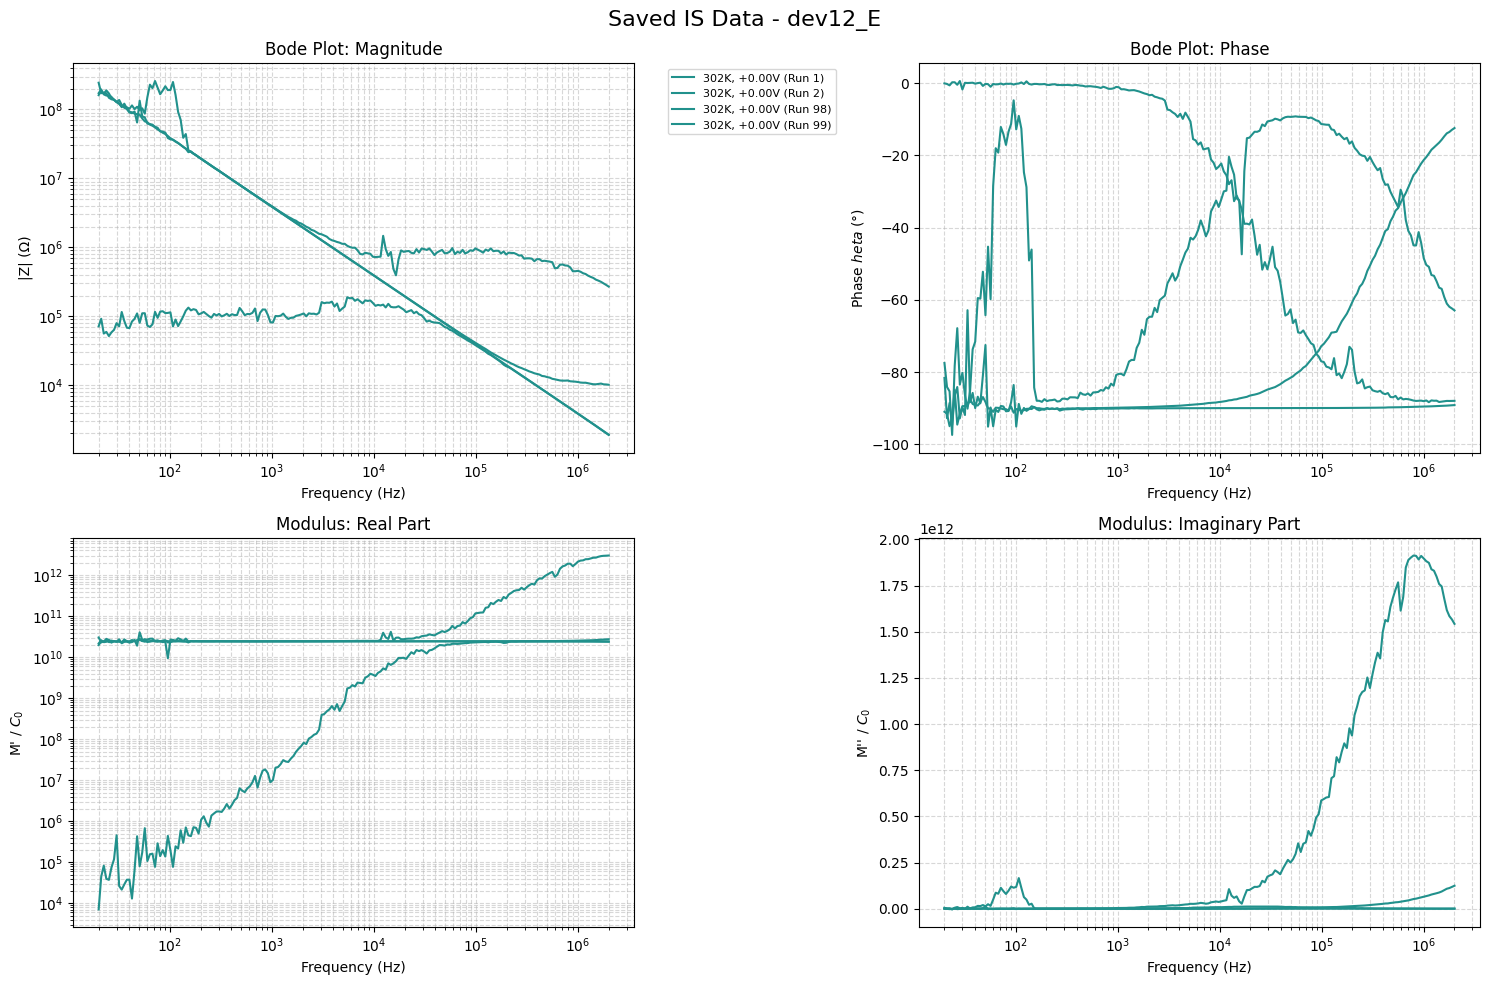

In [53]:
# Plot saved IS data from a specific folder without connecting to the instrument
# Use run_num to select specific runs (e.g., run_num=[1, 2]). Use None to plot all matching runs.
# Use temp_points and bias_points to filter only specific measurements (with tolerances).

sweep_name = "dev12_E"

load_and_plot_is(
    parent_dir=output_path, 
    sweep_name=sweep_name,
    #temp_points=[current_temp], # e.g. [300, 290] 
    #bias_points=dc_biases,    # e.g. [0.0, 1.0]
    run_num=None,
    log_y_left=True, 
    log_y_right=False,
   # y_range_left=[1e1,1e6],        # e.g. (1e3, 1e7)
    y_range_right=None,       # e.g. (-90, 90)
    remove_outliers=True     # Mask Z > 1e10, Z < 0, Phase > +/-180
)

In [14]:
temperatures = [295] + list(range(300, 340, 10))
print(temperatures)

[295, 300, 310, 320, 330]


## 2. Main Temperature & Bias Loop (IS Scans)

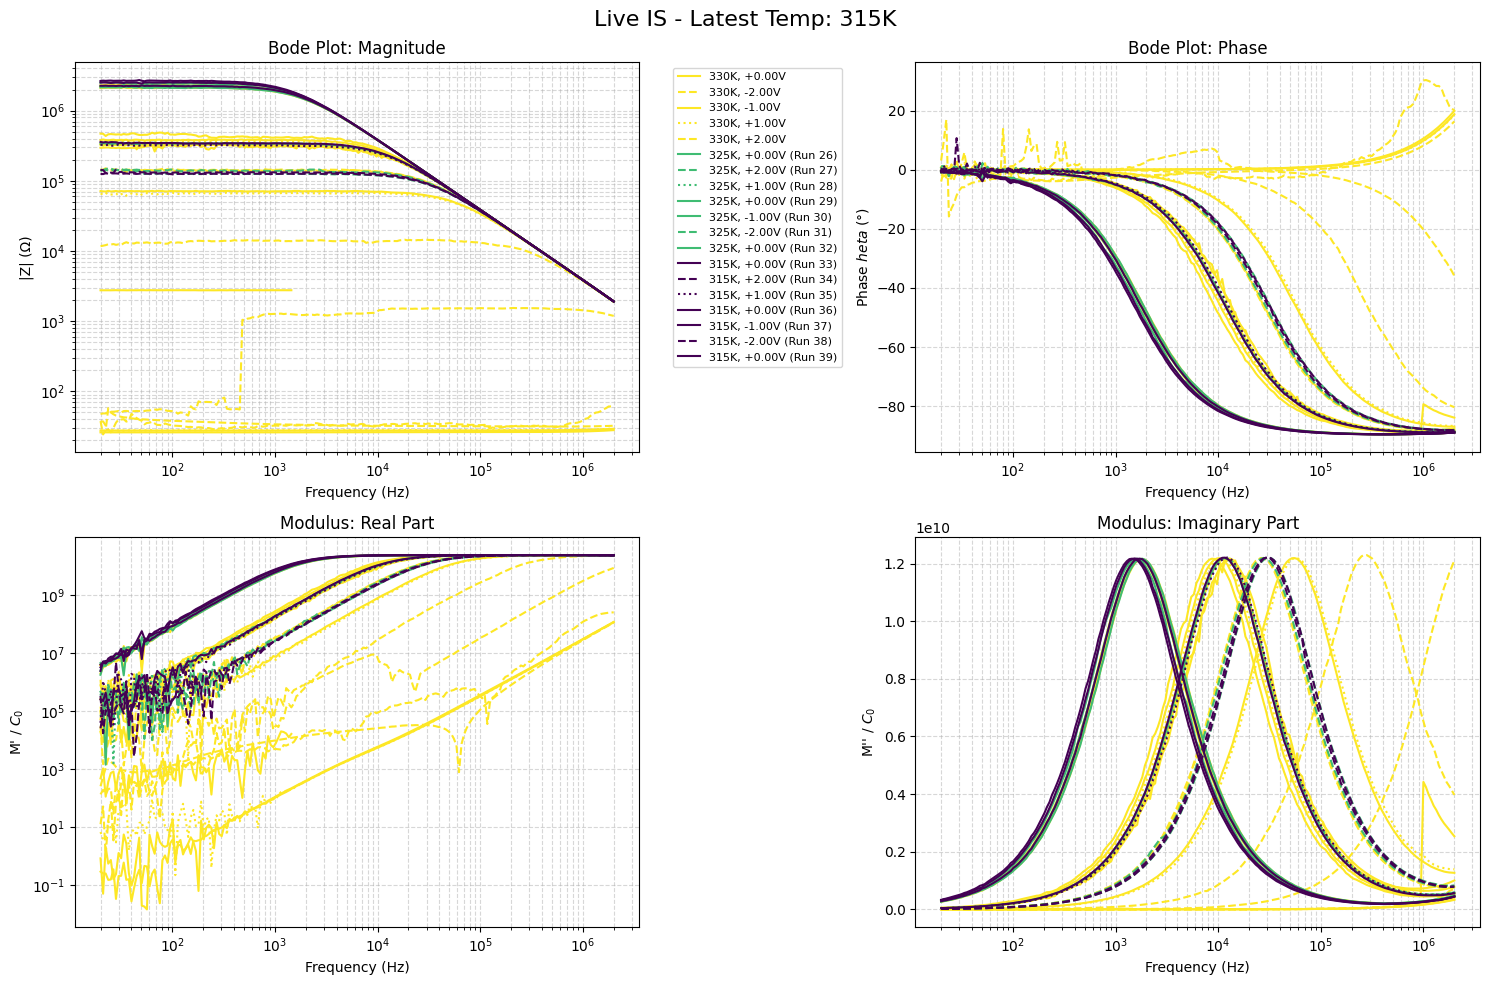


Temperature: 295 K
Setting temperature to 295 K...
Waiting for temperature stability...
  Current: 310.10 K | Target: 295 K | Elapsed: 170.2 min
    Controller mode: MODE 2
    Attempting to reactivate temperature control...


KeyboardInterrupt: 

In [44]:
# Define parameters for IS Sweep
temperatures = [325, 315, 295] #list(range(295, 340, 10))
print(temperatures)
dc_biases = dc_biases = [0.0, 2.0, 1.0, 0.0, -1.0, -2.0, 0.0]  # V  # V [-2.0 ,-1.0, 0.0, 1.0, 2.0, 0.0, -2.0, -1.0, 0.0, 1.0, 2.0, 0.0]  
ac_amplitude = 0.05 # V

sweep_name = "dev7_I_LRS"

# Run measurement
next_run = run_temperature_bias_sweep_with_live_plot(
    parent_dir=output_path,
    sweep_name=sweep_name,
    temp_points=temperatures,
    bias_points=dc_biases,
    janis_ctrl=janis,
    lcr_ctrl=lcr,
    freq_points=frequencies,
    Vrms=ac_amplitude,
    filename_suffix="_cal", 
    run_count_start=next_run,
    run_select=None,
    extra_settle_time=100,
    log_y_left=True,
    log_y_right=False,
    y_range_left=None,
    y_range_right=None,
    remove_outliers=True,
)

### Plot Main IS Measurements (Standalone)

In [ ]:
# Plot saved IS data for the main temperature/bias sweep
load_and_plot_is(
    parent_dir=output_path, 
    sweep_name=sweep_name,
    temp_points=temperatures, # uses the temperatures list from above
    bias_points=dc_biases,    # uses the dc_biases list from above
    run_num=None,
    log_y_left=True, 
    log_y_right=False,
    y_range_left=None,        
    y_range_right=None,
    remove_outliers=False
)

## 3. Capacitance-Voltage (CV) Scans

In [ ]:
# Define parameters for CV Sweep
Vmin = -5.0
Vmax = 5.0
Vstep = 0.5
Vrms = 0.1
cv_freq_points = [1e4, 1e5]
cycles = 1 

# Run measurement
next_run = run_cv_sweep_with_live_plot(
    parent_dir=output_path,
    sweep_name="CV_" + sweep_name,
    temp_points=temperatures,
    freq_points=cv_freq_points,
    Vmin=Vmin,
    Vmax=Vmax,
    Vstep=Vstep,
    Vrms=Vrms,
    cycles=cycles,
    janis_ctrl=janis,
    lcr_ctrl=lcr,
    filename_suffix="",
    run_count_start=next_run,
    run_select=None,
    extra_settle_time=30,
    log_y_left=False,
    log_y_right=False,
    y_range_left=None,
    y_range_right=None,
    remove_outliers=False
)

### Plot CV Measurements (Standalone)

In [ ]:
# Plot saved CV data
load_and_plot_cv(
    parent_dir=output_path, 
    sweep_name="CV_" + sweep_name,
    temp_points=temperatures,
    freq_points=cv_freq_points,
    run_num=None, 
    log_y_left=False, 
    log_y_right=False,
    y_range_left=None,
    y_range_right=None,
    remove_outliers=False
)

## 4. Time Scan (Drift) Measurement
Hold a DC voltage and monitor impedance over time.

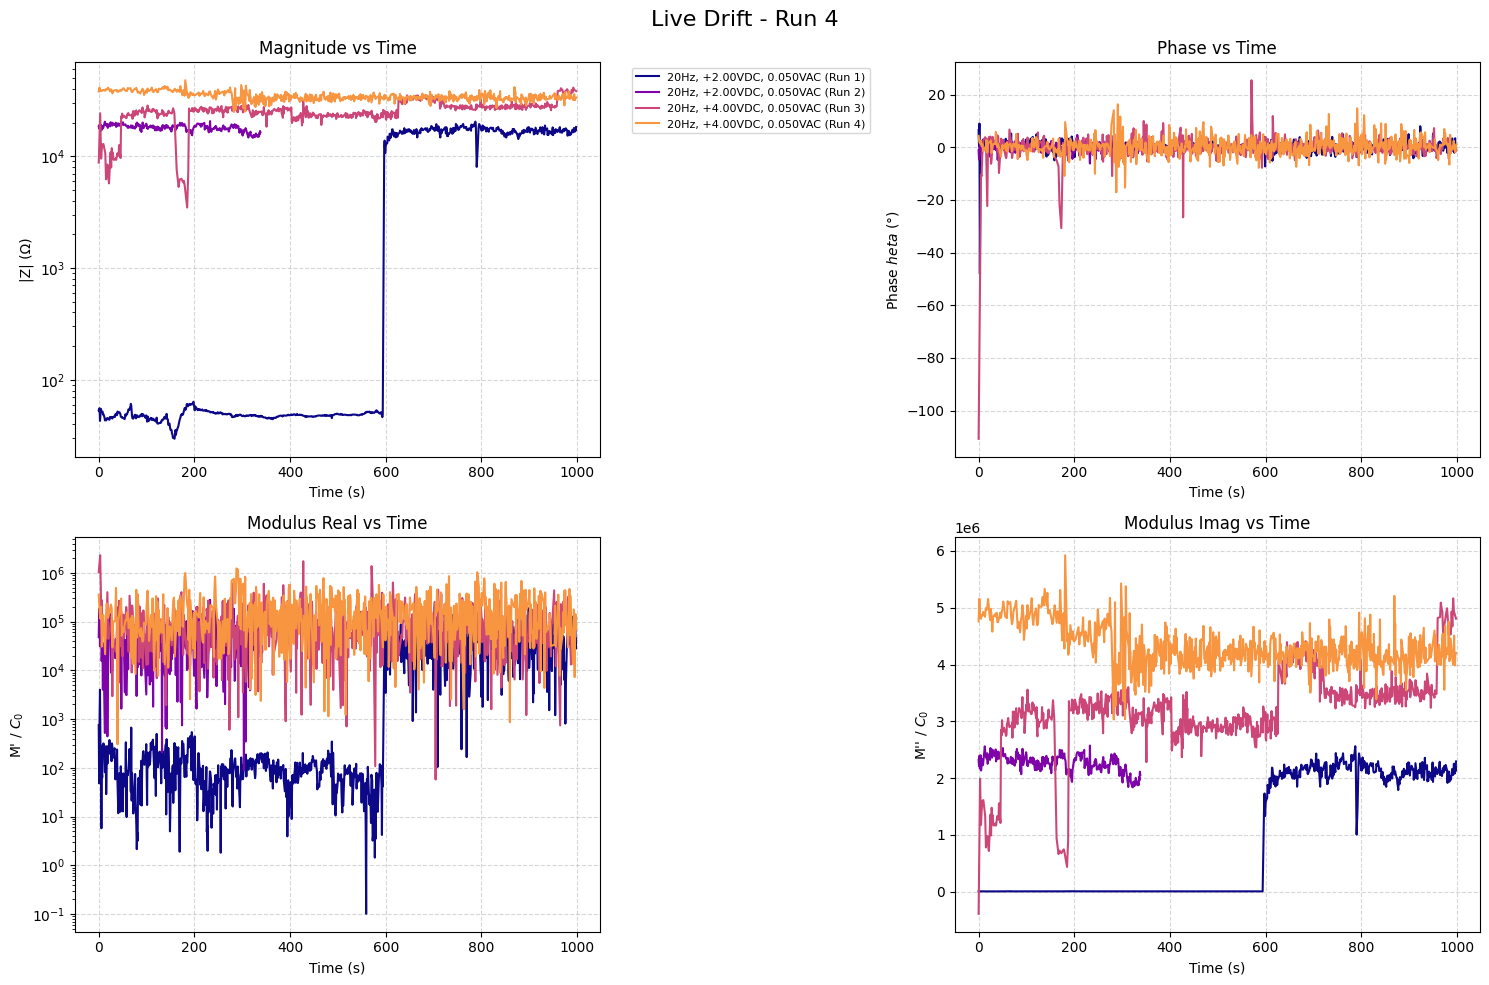


Putting LCR into true standby mode (0V AC, 0V DC, Trigger BUS)...

✓ TIME SCAN MEASUREMENTS COMPLETE! Next run: 5


In [41]:
# Define parameters for Time Scan
scan_duration = 1000 # Seconds to monitor
update_interval = 10 # Seconds between live plot updates

ts_temps = [330]#[janis.temperature] # Current temp by default, or [300, 280] etc.
ts_freqs = [20]      # Hz
ts_Vrms = [0.05]      # V
ts_Vdc = [4]        # V
ts_Z_threshold = 200e3 # e.g. 1000 for 1kOhm software stop

sweep_name = "dev7_I_LRS"

# Run measurement
next_run = run_time_scan_with_live_plot(
    parent_dir=output_path,
    sweep_name="TimeScan_" + sweep_name,
    temp_points=ts_temps,
    freq_points=ts_freqs,
    Vdc_points=ts_Vdc,
    Vrms_points=ts_Vrms,
    scan_duration=scan_duration,
    janis_ctrl=janis,
    lcr_ctrl=lcr,
    update_interval=update_interval,
    extra_settle_time=10,
    filename_suffix="",
    run_count_start= next_run,
    run_select=None,
    log_y_left=True,  # Z Magnitude (Linear by default here)
    log_y_right=False, # Phase
    y_range_left=None,
    y_range_right=None,
    remove_outliers=True
)

### Plot Time Scan (Standalone)

In [ ]:
# Plot saved Time Scan data
load_and_plot_time_scan(
    parent_dir=output_path, 
    sweep_name="TimeScan_" + sweep_name,
    freq_points=ts_freqs, 
    Vdc_points=ts_Vdc, 
    Vrms_points=ts_Vrms, 
    run_num=None,
    log_y_left=False, 
    log_y_right=False,
    y_range_left=None,
    y_range_right=None,
    remove_outliers=False
)